<a href="https://colab.research.google.com/github/easare377/Prithvi-EO-Segmentation/blob/main/Training_and_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import essential libraries for data manipulation, model building, and visualization.

In [ ]:
!pip install terratorch

In [1]:
import numpy as np
import os

In [2]:

import requests
from tqdm import tqdm

def download_file(url, dest_path, chunk_size=1024*1024):
    """
    Download a large file from a URL with a progress bar.
    Args:
        url (str): File URL.
        dest_path (str): Destination file path.
        chunk_size (int): Download chunk size in bytes.
    """
    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    with open(dest_path, 'wb') as file, tqdm(
        desc=f"Downloading {dest_path}",
        total=total,
        unit='B',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=chunk_size):
            size = file.write(data)
            bar.update(size)


In [3]:
train_file_path = r'D:\ssm_footprint_train.tfrecord'
val_file_path = r'D:\ssm_2019_footprint_val.tfrecord'
# Create the directory if it doesn't exist
# train_dir = os.path.dirname(train_file_path)
# if not os.path.exists(train_dir):
#     os.makedirs(train_dir)
# val_dir = os.path.dirname(val_file_path)
# if not os.path.exists(val_dir):
#     os.makedirs(val_dir)

In [ ]:

#download_file("https://sco-training.s3.us-east-2.amazonaws.com/ssm_footprint_train.tfrecord", train_file_path)

In [ ]:
# Create the directory if it doesn't exist

#download_file("https://sco-training.s3.us-east-2.amazonaws.com/ssm_footprint_val.tfrecord", val_file_path)

In [4]:
def zero_pad_array(input_array, new_shape):
    """
    Zero-pad the input_array to the specified new_shape.
    Args:
        input_array (numpy.ndarray): Input array of shape (height, width, ...).
        new_shape (tuple): Desired new shape (new_height, new_width, ...).
    Returns:
        numpy.ndarray: Zero-padded array of shape (new_height, new_width, ...).
    """
    h, w = input_array.shape[:2]
    new_h, new_w = new_shape[:2]
    pad_h = max(new_h - h, 0)
    pad_w = max(new_w - w, 0)
    pad_values = [(0, pad_h), (0, pad_w)]
    pad_values += [(0, 0)] * (input_array.ndim - 2)
    return np.pad(input_array, pad_values, mode='constant', constant_values=0)


Implement a PyTorch Dataset for loading images and masks from NPZ files, including normalization and padding.


Implement a PyTorch Dataset for loading images and masks from TFRecord files, including normalization and padding.

In [5]:
import os, struct
import numpy as np
import tensorflow as tf
import torch
from torch.utils.data import Dataset
import random

def _zero_pad_hw(arr_hw_or_hwc, target_hw):
    th, tw = target_hw
    if arr_hw_or_hwc.ndim == 2:
        h, w = arr_hw_or_hwc.shape
        pad = ((max((th-h)//2,0), max(th-h,0) - max((th-h)//2,0)),
               (max((tw-w)//2,0), max(tw-w,0) - max((tw-w)//2,0)))
    else:
        h, w, c = arr_hw_or_hwc.shape
        pad = ((max((th-h)//2,0), max(th-h,0) - max((th-h)//2,0)),
               (max((tw-w)//2,0), max(tw-w,0) - max((tw-w)//2,0)),
               (0,0))
    return np.pad(arr_hw_or_hwc, pad, mode='constant')

def _zero_pad_cthw(X, target_hw):
    # pad only H,W for (C,T,H,W)
    C,T,H,W = X.shape
    img = np.transpose(X, (2,3,0,1)).reshape(H, W, C*T)      # (H,W,C*T)
    img = _zero_pad_hw(img, target_hw)
    H2, W2, CT = img.shape
    img = np.transpose(img, (2,0,1)).reshape(C, T, H2, W2)
    return img

class MineFootprintTFRecordDataset(Dataset):
    # Your 6-band stats; if C != 6 we fall back to per-sample normalization
    MEAN = np.array([1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0], dtype=np.float32)
    STD  = np.array([2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0], dtype=np.float32)

    _feature_desc = {
        "image_raw": tf.io.FixedLenFeature([], tf.string),
        "mask_raw":  tf.io.FixedLenFeature([], tf.string),
        "height":    tf.io.FixedLenFeature([], tf.int64),
        "width":     tf.io.FixedLenFeature([], tf.int64),
        "channels":  tf.io.FixedLenFeature([], tf.int64),
        "timesteps": tf.io.FixedLenFeature([], tf.int64),
        "temporal_coords": tf.io.VarLenFeature(tf.float32),  # length = 2*T
        "location_coords": tf.io.FixedLenFeature([2], tf.float32),
    }

    def __init__(self, tfrecord_file, transform=None, pad_to=(224, 224)):
        super().__init__()
        self.tfrecord_path = os.fspath(tfrecord_file)
        self.transform = transform
        self.pad_to = pad_to
        self._offsets = self._scan_index()
        self._fh = open(self.tfrecord_path, 'rb')

    def _scan_index(self):
        offsets = []
        with open(self.tfrecord_path, 'rb') as f:
            pos = 0
            while True:
                header = f.read(12)                  # 8 len + 4 len_crc
                if not header:
                    break
                rec_len = struct.unpack('<Q', header[:8])[0]
                offsets.append(pos)
                pos += 12 + rec_len + 4             # header + data + data_crc
                f.seek(pos)
        return offsets

    def _read_record(self, offset):
        self._fh.seek(offset)
        header = self._fh.read(12)
        rec_len = struct.unpack('<Q', header[:8])[0]
        data = self._fh.read(rec_len)
        _ = self._fh.read(4)
        return data

    def __len__(self):
        return len(self._offsets)

    def _normalize_cthw(self, X):
        C,T,H,W = X.shape
        if C == len(self.MEAN):
            mean = self.MEAN.reshape(C,1,1,1)
            std  = (self.STD + 1e-6).reshape(C,1,1,1)
            return (X - mean) / std
        # Fallback: per-sample per-channel across (T,H,W)
        m = X.mean(axis=(1,2,3), keepdims=True)
        s = X.std(axis=(1,2,3), keepdims=True) + 1e-6
        return (X - m) / s

    def _apply_albu_over_time(self, X, mask):
        """Apply Albumentations over (H,W) consistently for all time steps:
           reshape (C,T,H,W) -> (H,W,C*T), apply, then back."""
        C,T,H,W = X.shape
        img = np.transpose(X, (2,3,0,1)).reshape(H, W, C*T)   # (H,W,C*T)

        aug = self.transform(image=img, mask=mask)
        img_aug, msk_aug = aug["image"], aug["mask"]

        # Handle ToTensorV2 in pipeline
        if isinstance(img_aug, torch.Tensor):
            # Albumentations returns CHW if ToTensorV2; convert to HWC
            img_aug = img_aug.cpu().numpy().transpose(1,2,0)
        if isinstance(msk_aug, torch.Tensor):
            msk_aug = msk_aug.cpu().numpy()

        H2, W2, CT2 = img_aug.shape
        if CT2 % C != 0:
            raise RuntimeError(f"Aug channels {CT2} not divisible by C={C}")
        T2 = CT2 // C
        X2 = np.transpose(img_aug, (2,0,1)).reshape(C, T2, H2, W2)
        return X2, msk_aug

    def __getitem__(self, idx):
        serialised = self._read_record(self._offsets[idx])
        ex = tf.io.parse_single_example(serialised, self._feature_desc)

        H = int(ex["height"])
        W = int(ex["width"])
        C = int(ex["channels"])
        T = int(ex["timesteps"])

        img = np.frombuffer(ex["image_raw"].numpy(), dtype=np.float32).reshape((C, T, H, W))
        msk = np.frombuffer(ex["mask_raw"].numpy(),  dtype=np.uint8).reshape((H, W))

        img = np.nan_to_num(img, nan=0.0)
        msk = np.nan_to_num(msk.astype(np.float32), nan=0.0).astype(np.uint8)

        # Normalize per channel (broadcast over T,H,W)
        img = self._normalize_cthw(img)

        # Center-pad to target size
        img = _zero_pad_cthw(img, self.pad_to)       # (C,T,H2,W2)
        msk = _zero_pad_hw(msk, self.pad_to)         # (H2,W2)

        # Temporal/Location coords
        temporal_coords = tf.sparse.to_dense(ex["temporal_coords"]).numpy().astype(np.float32).reshape(T, 2)
        location_coords = ex["location_coords"].numpy().astype(np.float32)   # (2,)

        # Optional Albumentations over time (geom only)
        if self.transform is not None:
            img, msk = self._apply_albu_over_time(img, msk)

        # To torch
        img = torch.from_numpy(img).float()                  # (C,T,H,W)
        msk = torch.from_numpy(msk).long()                   # (H,W)
        temporal_coords = torch.from_numpy(temporal_coords)  # (T,2)
        location_coords = torch.from_numpy(location_coords)  # (2,)

        return {
            "image": img,  # (C,T,H,W)
            "temporal_coords": temporal_coords,  # (T,2)
            "location_coords": location_coords,  # (2,)
            "mask": msk      # (H,W)
        }

    def __del__(self):
        try:
            if hasattr(self, "_fh") and self._fh and not self._fh.closed:
                self._fh.close()
        except Exception:
            pass

# -------- collate: pick ONE random timestep length for the whole batch --------
def make_temporal_collate(max_T=10, min_T=1):
    assert 1 <= min_T <= max_T
    def _collate(batch):
        t_sel = 4 #random.randint(min_T, max_T)
        imgs, tcoords, lcoords, masks = [], [], [], []
        for sample in batch:
            X = sample["image"]                 # (C,T,H,W)
            T = X.shape[1]
            X = X[:, -t_sel:, :, :]             # keep LAST t_sel
            imgs.append(X)

            tc = sample["temporal_coords"]      # (T,2)
            tcoords.append(tc[-t_sel:, :])

            lcoords.append(sample["location_coords"])   # (2,)
            masks.append(sample["mask"])         # (H,W)

        imgs   = torch.stack(imgs,   dim=0)      # (B,C,t_sel,H,W)
        tcoords= torch.stack(tcoords,dim=0)      # (B,t_sel,2)
        lcoords= torch.stack(lcoords,dim=0)      # (B,2)
        masks  = torch.stack(masks,  dim=0)      # (B,H,W)
        return {"image": imgs,
                "temporal_coords": tcoords,
                "location_coords": lcoords,
                "mask": masks
               }
    return _collate

def make_temporal_collate(timesteps=4):
    #assert 1 <= min_T <= max_T
    def _collate(batch):
        t_sel = timesteps #random.randint(min_T, max_T)
        imgs, tcoords, lcoords, masks = [], [], [], []
        for sample in batch:
            X = sample["image"]                 # (C,T,H,W)
            T = X.shape[1]
            X = X[:, -t_sel:, :, :]             # keep LAST t_sel
            imgs.append(X)

            tc = sample["temporal_coords"]      # (T,2)
            tcoords.append(tc[-t_sel:, :])

            lcoords.append(sample["location_coords"])   # (2,)
            masks.append(sample["mask"])         # (H,W)

        imgs   = torch.stack(imgs,   dim=0)      # (B,C,t_sel,H,W)
        tcoords= torch.stack(tcoords,dim=0)      # (B,t_sel,2)
        lcoords= torch.stack(lcoords,dim=0)      # (B,2)
        masks  = torch.stack(masks,  dim=0)      # (B,H,W)
        return {"image": imgs,
                "temporal_coords": tcoords,
                "location_coords": lcoords,
                "mask": masks
               }
    return _collate


In [6]:
import os, struct
import numpy as np
import tensorflow as tf
import torch
from torch.utils.data import Dataset
import random

def _zero_pad_hw(arr_hw_or_hwc, target_hw):
    th, tw = target_hw
    if arr_hw_or_hwc.ndim == 2:
        h, w = arr_hw_or_hwc.shape
        pad = ((max((th-h)//2,0), max(th-h,0) - max((th-h)//2,0)),
               (max((tw-w)//2,0), max(tw-w,0) - max((tw-w)//2,0)))
    else:
        h, w, c = arr_hw_or_hwc.shape
        pad = ((max((th-h)//2,0), max(th-h,0) - max((th-h)//2,0)),
               (max((tw-w)//2,0), max(tw-w,0) - max((tw-w)//2,0)),
               (0,0))
    return np.pad(arr_hw_or_hwc, pad, mode='constant')

def _zero_pad_cthw(X, target_hw):
    C,T,H,W = X.shape
    img = np.transpose(X, (2,3,0,1)).reshape(H, W, C*T)      # (H,W,C*T)
    img = _zero_pad_hw(img, target_hw)
    H2, W2, CT = img.shape
    img = np.transpose(img, (2,0,1)).reshape(C, T, H2, W2)
    return img

class MineFootprintTFRecordDataset(Dataset):
    MEAN = np.array([1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0], dtype=np.float32)
    STD  = np.array([2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0], dtype=np.float32)

    _feature_desc = {
        "image_raw": tf.io.FixedLenFeature([], tf.string),
        "mask_raw":  tf.io.FixedLenFeature([], tf.string),
        "height":    tf.io.FixedLenFeature([], tf.int64),
        "width":     tf.io.FixedLenFeature([], tf.int64),
        "channels":  tf.io.FixedLenFeature([], tf.int64),
        "timesteps": tf.io.FixedLenFeature([], tf.int64),
        "temporal_coords": tf.io.VarLenFeature(tf.float32),  # length = 2*T
        "location_coords": tf.io.FixedLenFeature([2], tf.float32),
    }

    def __init__(self, tfrecord_file, transform=None, pad_to=(224, 224)):
        super().__init__()
        self.tfrecord_path = os.fspath(tfrecord_file)
        self.transform = transform
        self.pad_to = pad_to
        self._offsets = self._scan_index()
        self._fh = open(self.tfrecord_path, 'rb')

    def _scan_index(self):
        offsets = []
        with open(self.tfrecord_path, 'rb') as f:
            pos = 0
            while True:
                header = f.read(12)
                if not header:
                    break
                rec_len = struct.unpack('<Q', header[:8])[0]
                offsets.append(pos)
                pos += 12 + rec_len + 4
                f.seek(pos)
        return offsets

    def _read_record(self, offset):
        self._fh.seek(offset)
        header = self._fh.read(12)
        rec_len = struct.unpack('<Q', header[:8])[0]
        data = self._fh.read(rec_len)
        _ = self._fh.read(4)
        return data

    def __len__(self):
        return len(self._offsets)

    def _apply_albu_over_time(self, X, mask):
        """Apply Albumentations over (H,W) consistently for all T."""
        C,T,H,W = X.shape
        img = np.transpose(X, (2,3,0,1)).reshape(H, W, C*T)   # (H,W,C*T)

        aug = self.transform(image=img, mask=mask)
        img_aug, msk_aug = aug["image"], aug["mask"]

        # Handle ToTensorV2 in pipeline
        if isinstance(img_aug, torch.Tensor):
            img_aug = img_aug.cpu().numpy().transpose(1,2,0)
        if isinstance(msk_aug, torch.Tensor):
            msk_aug = msk_aug.cpu().numpy()

        H2, W2, CT2 = img_aug.shape
        if CT2 % C != 0:
            raise RuntimeError(f"Aug channels {CT2} not divisible by C={C}")
        T2 = CT2 // C
        X2 = np.transpose(img_aug, (2,0,1)).reshape(C, T2, H2, W2)
        return X2, msk_aug

    def __getitem__(self, idx):
        serialised = self._read_record(self._offsets[idx])
        ex = tf.io.parse_single_example(serialised, self._feature_desc)

        H = int(ex["height"]); W = int(ex["width"])
        C = int(ex["channels"]); T = int(ex["timesteps"])

        img = np.frombuffer(ex["image_raw"].numpy(), dtype=np.float32).reshape((C, T, H, W))
        msk = np.frombuffer(ex["mask_raw"].numpy(),  dtype=np.uint8).reshape((H, W))

        img = np.nan_to_num(img, nan=0.0)
        msk = np.nan_to_num(msk.astype(np.float32), nan=0.0).astype(np.uint8)

        # -------- NEW: build temporal_mask BEFORE normalization ---------------
        # frame is real if any pixel is non-zero across channels
        frame_energy = img.sum(axis=(0,2,3))            # (T,)
        temporal_mask = (frame_energy > 0).astype(np.float32)  # 1=real, 0=padded

        # -------- normalize ONLY real frames; keep padded frames at exact zero
        if C == len(self.MEAN):
            mean = self.MEAN.reshape(C,1,1,1)
            std  = (self.STD + 1e-6).reshape(C,1,1,1)
        else:
            # per-sample fallback (across T,H,W for each channel) using only real frames
            if temporal_mask.any():
                real = img[:, temporal_mask.astype(bool), :, :]
                mean = real.mean(axis=(1,2,3), keepdims=True)
                std  = real.std(axis=(1,2,3), keepdims=True) + 1e-6
            else:
                mean = np.zeros((C,1,1,1), dtype=np.float32)
                std  = np.ones((C,1,1,1), dtype=np.float32)

        img_norm = (img - mean) / std
        # zero-out padded frames again
        if (temporal_mask == 0).any():
            padded_idx = np.where(temporal_mask == 0)[0]
            img_norm[:, padded_idx, :, :] = 0.0
        img = img_norm
        # ---------------------------------------------------------------------

        # Center-pad to target size
        img = _zero_pad_cthw(img, self.pad_to)   # (C,T,H2,W2)
        msk = _zero_pad_hw(msk, self.pad_to)     # (H2,W2)

        # coords
        temporal_coords = tf.sparse.to_dense(ex["temporal_coords"]).numpy().astype(np.float32).reshape(T, 2)
        location_coords = ex["location_coords"].numpy().astype(np.float32)   # (2,)

        # Optional Albumentations (geom only) — preserves zeros for padded frames
        if self.transform is not None:
            img, msk = self._apply_albu_over_time(img, msk)

        # To torch
        img = torch.from_numpy(img).float()                         # (C,T,H,W)
        msk = torch.from_numpy(msk).long()                          # (H,W)
        temporal_coords = torch.from_numpy(temporal_coords)         # (T,2)
        location_coords = torch.from_numpy(location_coords)         # (2,)
        temporal_mask_t = torch.from_numpy(temporal_mask).float()   # (T,)

        return {
            "image": img,
            "temporal_coords": temporal_coords,
            "location_coords": location_coords,
            "temporal_mask": temporal_mask_t,   # <—— NEW
            "mask": msk
        }

    def __del__(self):
        try:
            if hasattr(self, "_fh") and self._fh and not self._fh.closed:
                self._fh.close()
        except Exception:
            pass


def make_temporal_collate(timesteps=1):
    def _collate(batch):
        t_sel = timesteps
        imgs, tcoords, lcoords, tmasks, masks = [], [], [], [], []
        for sample in batch:
            X  = sample["image"]                 # (C,T,H,W)
            tc = sample["temporal_coords"]       # (T,2)
            tm = sample["temporal_mask"]         # (T,)
            lc = sample["location_coords"]       # (2,)
            ms = sample["mask"]                  # (H,W)

            X  = X[:, -t_sel:, :, :]
            # reshape x to (C, H, W)
            X = X.reshape(X.shape[0], X.shape[2], X.shape[3])  # (C,H,W)
            tc = tc[-t_sel:, :]
            tm = tm[-t_sel:]

            imgs.append(X)
            tcoords.append(tc)
            tmasks.append(tm)
            lcoords.append(lc)
            masks.append(ms)

        imgs    = torch.stack(imgs,    dim=0)  # (B,C,t_sel,H,W)
        tcoords = torch.stack(tcoords, dim=0)  # (B,t_sel,2)
        tmasks  = torch.stack(tmasks,  dim=0)  # (B,t_sel)
        lcoords = torch.stack(lcoords, dim=0)  # (B,2)
        masks   = torch.stack(masks,   dim=0)  # (B,H,W)

        return {
            "image": imgs,
            "temporal_coords": tcoords,
            "temporal_mask": tmasks,       # <—— pass to model if you support mask tokens
            "location_coords": lcoords,
            "mask": masks
        }
    return _collate


Set up an Albumentations transformation pipeline for data augmentation during training.

In [7]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
# Define transformation pipeline
transform = A.Compose([
    A.RandomRotate90(p=0.7),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    ToTensorV2(),
])

# Prepare Training Dataset and DataLoader
Initialize the training dataset and DataLoader for batch processing and shuffling.

# Prepare TFRecord Training Dataset and DataLoader
Initialize the TFRecord-based training dataset and DataLoader for batch processing and shuffling.

In [8]:
TIMESTEPS = 1
batch_size = 8
train_dataset = MineFootprintTFRecordDataset(train_file_path, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True,drop_last=True, collate_fn=make_temporal_collate(TIMESTEPS))

In [30]:
val_dataset = MineFootprintTFRecordDataset(val_file_path, transform=transform)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True, collate_fn=make_temporal_collate(TIMESTEPS))

In [12]:
len(val_dataset)

2016

In [17]:
#Print the shape of the training data
for batch in train_loader:
    x = batch["image"]               # (B,C,t',H,W)
    tcoords = batch["temporal_coords"] # (B,t',2)
    lcoords = batch["location_coords"] # (B,2)
    tmasks = batch["temporal_mask"]    # (B,t')
    y = batch["mask"]                  # (B,H,W)

    print("Batch image shape:", x.shape)
    print("Batch temporal coords shape:", tcoords.shape)
    print("Batch location coords shape:", lcoords.shape)
    print("Batch temporal masks shape:", tmasks.shape)
    print("Batch mask shape:", y.shape)
    break  # Just print the first batch

Batch image shape: torch.Size([2, 6, 224, 224])
Batch temporal coords shape: torch.Size([2, 1, 2])
Batch location coords shape: torch.Size([2, 2])
Batch temporal masks shape: torch.Size([2, 1])
Batch mask shape: torch.Size([2, 224, 224])


In [18]:
import random, math
import numpy as np
import torch
import matplotlib.pyplot as plt

def visualize_random_temporal_rgb(
    ds,
    idx: int | None = None,
    rgb_indices=(2, 1, 0),      # (R,G,B) from your band order [BLUE,GREEN,RED,NIR_NARROW,SWIR_1,SWIR_2]
    scale_divisor: float = 3000.0,
    max_cols: int = 5,
    figsize=(16, 6),
    title: str | None = None,
):
    """
    Visualize RGB for each timestep (including zero-padded frames) from MineFootprintTFRecordDataset.

    - Picks a random index if `idx` is None.
    - Un-normalizes using ds.MEAN / ds.STD (expects shape (6,)).
    - Then scales by (img / scale_divisor) * 255 → uint8 for display.
    - Uses temporal_coords to label each frame; [0,0] will be marked as 'padded'.

    Args:
        ds: MineFootprintTFRecordDataset instance
        idx: optional dataset index; if None, a random one is chosen
        rgb_indices: channel indices for R,G,B within the C dimension
        scale_divisor: values divided by this, then mapped to 0..255
        max_cols: maximum columns in the subplot grid
        figsize: matplotlib figure size
        title: optional figure title
    """
    assert hasattr(ds, "MEAN") and hasattr(ds, "STD"), "Dataset must expose MEAN and STD."
    if idx is None:
        idx = random.randrange(len(ds))

    sample = ds[idx]  # {'image': (C,T,H,W) float, 'temporal_coords': (T,2), 'mask': (H,W), ...}

    X = sample["image"]            # torch.Tensor (C,T,H,W)
    tc = sample["temporal_coords"] # torch.Tensor (T,2)

    if isinstance(X, torch.Tensor):
        X = X.detach().cpu().numpy()
    if isinstance(tc, torch.Tensor):
        tc = tc.detach().cpu().numpy()

    C, T, H, W = X.shape

    # ---- unnormalize (inverse of (x - mean) / std) ----
    mean = np.asarray(ds.MEAN, dtype=np.float32).reshape(-1, 1, 1, 1)
    std  = (np.asarray(ds.STD,  dtype=np.float32) + 1e-6).reshape(-1, 1, 1, 1)
    if mean.shape[0] != C:
        # Fallback: per-sample stats over (T,H,W) if band count differs
        m = X.mean(axis=(1,2,3), keepdims=True)
        s = X.std(axis=(1,2,3), keepdims=True) + 1e-6
        X_unnorm = X * s + m
    else:
        X_unnorm = X * std + mean

    # ---- prepare plotting grid ----
    ncols = min(T, max_cols)
    nrows = math.ceil(T / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    for t in range(T):
        ax = axes[t]
        # Extract RGB per timestep
        r, g, b = rgb_indices
        rgb = np.stack([X_unnorm[r, t], X_unnorm[g, t], X_unnorm[b, t]], axis=-1)  # (H,W,3)

        # Scale to 0..255 via /3000
        rgb = np.clip(rgb / scale_divisor, 0.0, 1.0)
        rgb = (rgb * 255.0).round().astype(np.uint8)

        ax.imshow(rgb)
        ax.axis("off")

        year, doy = tc[t].tolist()
        if year == 0 and doy == 0:
            ax.set_title(f"T{t+1}: padded", fontsize=9)
        else:
            ax.set_title(f"T{t+1}: {int(year)} (doy={int(doy)})", fontsize=9)

    # Hide any extra axes
    for k in range(T, nrows * ncols):
        axes[k].axis("off")

    if title is None:
        title = f"Sample idx={idx}  |  C={C}, T={T}, H×W={H}×{W}"
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()


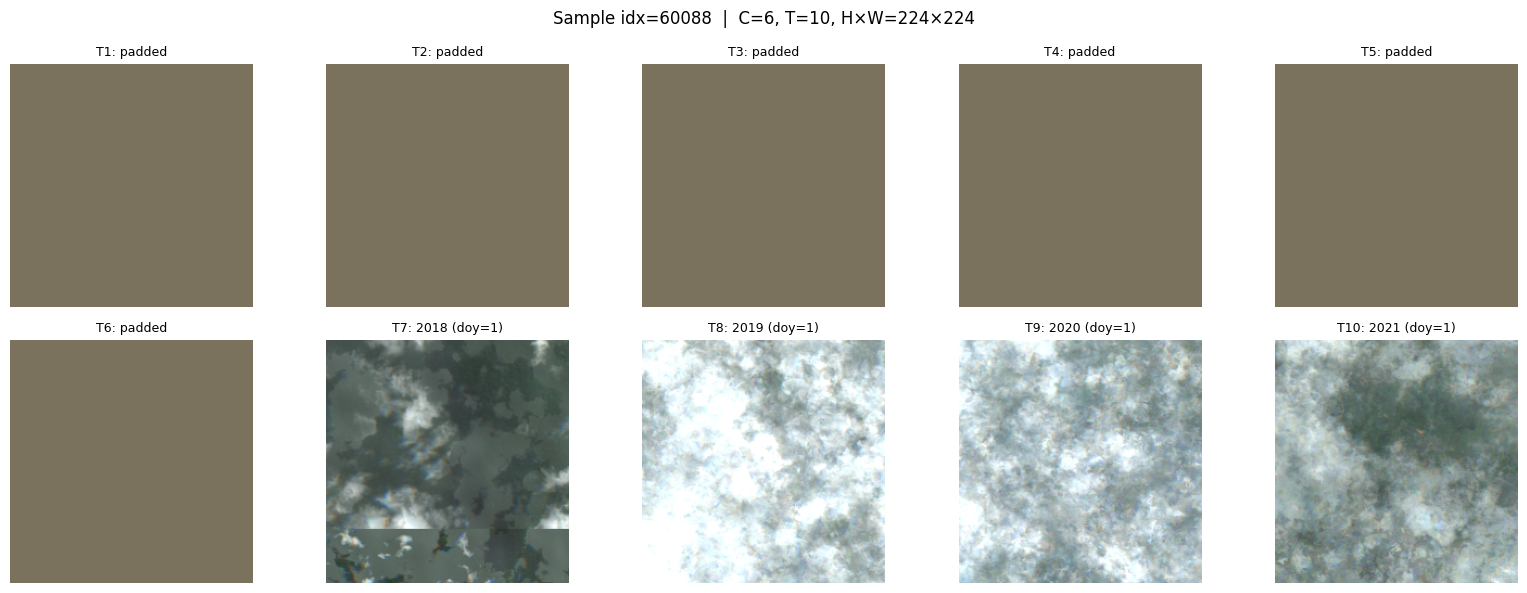

In [19]:
# Just call it with your dataset
visualize_random_temporal_rgb(train_dataset)  # random sample

# # Or pick a specific index
# visualize_random_temporal_rgb(train_dataset, idx=42, rgb_indices=(2,1,0))


# Define Semantic Segmentation Model
Create a semantic segmentation model using the TerraTorch library with a Prithvi EO backbone.

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Define a block with two convolutional layers, BatchNorm, and ReLU activation.
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        return self.double_conv(x)

# Down block: max pooling followed by a double convolution.
class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
        
    def forward(self, x):
        return self.maxpool_conv(x)

# Up block: upsampling (using bilinear interpolation) followed by concatenation of the skip connection and a double convolution.
class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super(Up, self).__init__()
        self.bilinear = bilinear
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)
        
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Calculate difference in spatial dimensions and pad x1 accordingly.
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        # Concatenate along the channels dimension.
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

# Output convolution to map features to the desired number of classes.
class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        
    def forward(self, x):
        return self.conv(x)

# Define the full UNet architecture.
class UNet(nn.Module):
    def __init__(self, n_channels=6, n_classes=1, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)       # Initial conv block
        self.down1 = Down(64, 128)                    # Downsample 1
        self.down2 = Down(128, 256)                   # Downsample 2
        self.down3 = Down(256, 512)                   # Downsample 3
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)        # Downsample 4 (bottleneck)
        self.up1 = Up(1024, 512 // factor, bilinear)    # Upsample 1
        self.up2 = Up(512, 256 // factor, bilinear)     # Upsample 2
        self.up3 = Up(256, 128 // factor, bilinear)     # Upsample 3
        self.up4 = Up(128, 64, bilinear)              # Upsample 4
        self.outc = OutConv(64, n_classes)            # Final output conv

    def forward(self, x):
        x1 = self.inc(x)       # (B, 64, H, W)
        x2 = self.down1(x1)    # (B, 128, H/2, W/2)
        x3 = self.down2(x2)    # (B, 256, H/4, W/4)
        x4 = self.down3(x3)    # (B, 512, H/8, W/8)
        x5 = self.down4(x4)    # (B, 1024/factor, H/16, W/16)
        x = self.up1(x5, x4)   # (B, 512/factor, H/8, W/8)
        x = self.up2(x, x3)    # (B, 256/factor, H/4, W/4)
        x = self.up3(x, x2)    # (B, 128/factor, H/2, W/2)
        x = self.up4(x, x1)    # (B, 64, H, W)
        logits = self.outc(x)  # (B, n_classes, H, W)
        return logits

In [21]:
model = UNet(n_channels=6, n_classes=3, bilinear=True)
dummy_input = torch.randn(2, 6, 514, 514)  # Batch size 2, 6 channels, 224x224 image
output = model(dummy_input)
print("Output shape:", output.shape)  # Expected: (2, 1, 224, 224)

Output shape: torch.Size([2, 3, 514, 514])


# Load Pretrained Model Weights
Load pretrained weights into the segmentation model for transfer learning or evaluation.

In [27]:
#load pretrained weights
from pathlib import Path
model_save_path  = Path("prithvi_state_dict.pt")
#model.load_state_dict(torch.load(model_save_path))


Display the number of trainable and total parameters in the model.

In [22]:
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total params:", sum(p.numel() for p in model.parameters()))

Trainable params: 13397187
Total params: 13397187


# Example Model Forward Pass
Demonstrate a forward pass through the model with dummy data for testing.

# Set Device, Loss Function, and Optimizer
Configure the device (CPU/GPU), loss function, and optimizer for training.

In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Define loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1.5e-5)
print(device)

cuda


# Training Loop
Implement the training loop for the segmentation model, including loss calculation and model checkpointing.

In [16]:
#load pretrained weights
from pathlib import Path
model_save_path  = Path("prithvi_state_dict.pt")

In [25]:
import torch
from time import time
from datetime import timedelta
from tqdm import tqdm

def _get_logits(out):
    """Handle either raw tensor or objects with `.output`."""
    return out.output if hasattr(out, "output") else out

@torch.no_grad()
def evaluate(model, criterion, val_loader, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in val_loader:
        images  = batch["image"].to(device)                        # (B,C,T,H,W) or (B,C,H,W)
        masks   = batch["mask"].to(device).long()                  # (B,H,W)
        tcoords = batch["temporal_coords"].to(device)              # (B,T,2) or (B,1,2)
        lcoords = batch["location_coords"].to(device)              # (B,2)

        logits = _get_logits(model(images))  # (B,K,H,W)
        loss = criterion(logits, masks)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)                        # (B,H,W)
        correct += (preds == masks).sum().item()
        total   += masks.numel()

    avg_loss = running_loss / len(val_loader.dataset)
    pixel_acc = correct / total if total > 0 else 0.0
    return avg_loss, pixel_acc

def train(model, criterion, optimizer, train_loader, val_loader, device, num_epochs, model_save_path):
    model.to(device)

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        seen_samples = 0

        pbar = tqdm(
            enumerate(train_loader, 1),
            total=len(train_loader),
            desc=f"Epoch {epoch}/{num_epochs}",
            ncols=120,
            unit="batch",
            leave=False
        )
        start_time = time()

        for step, batch in pbar:
            images  = batch["image"].to(device)
            masks   = batch["mask"].to(device).long()
            tmasks  = batch["temporal_mask"].to(device)
            tcoords = batch["temporal_coords"].to(device)
            lcoords = batch["location_coords"].to(device)

            bsz = images.size(0)
            optimizer.zero_grad()

            logits = _get_logits(model(images))
            #logits2d = logits.mean(dim=2)             # [B, C, H, W]
            #logits2d = logits.median(dim=2).values
            #loss = criterion(logits2d, masks.long())  # masks: [B, H, W]

            loss = criterion(logits, masks.long())
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * bsz
            seen_samples += bsz
            avg_loss_so_far = running_loss / seen_samples

            elapsed = time() - start_time
            batches_left = len(train_loader) - step
            eta = timedelta(seconds=int(elapsed / max(step,1) * batches_left))
            pbar.set_postfix_str(f"train_loss: {avg_loss_so_far:.4f} - ETA: {eta}")

        train_epoch_loss = running_loss / seen_samples

        # ---------- Validation ----------
        val_loss, val_acc = evaluate(model, criterion, val_loader, device)

        # ---------- Save ----------
        torch.save(model.state_dict(), model_save_path)

        print(f"\n📌 Epoch {epoch}/{num_epochs} "
              f"— train_loss: {train_epoch_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4%}")

# usage:
# train(model, criterion, optimizer, train_loader, val_loader, device, num_epochs=50, model_save_path=model_save_path)


In [43]:
# freeze encoder for 3–5 epochs first
for p in model.encoder.parameters():
    p.requires_grad = False

In [32]:
train(model, criterion, optimizer, train_loader, val_loader, device, num_epochs=50, model_save_path=model_save_path)


📌 Epoch 1/50 — train_loss: 0.0265 | val_loss: 0.0558 | val_acc: 97.8255%



📌 Epoch 2/50 — train_loss: 0.0253 | val_loss: 0.0537 | val_acc: 97.9238%



📌 Epoch 3/50 — train_loss: 0.0245 | val_loss: 0.0551 | val_acc: 97.9026%



📌 Epoch 4/50 — train_loss: 0.0238 | val_loss: 0.0508 | val_acc: 98.0614%



📌 Epoch 5/50 — train_loss: 0.0233 | val_loss: 0.0507 | val_acc: 98.0825%



📌 Epoch 6/50 — train_loss: 0.0229 | val_loss: 0.0592 | val_acc: 97.6704%


KeyboardInterrupt: 

Resident portal

In [54]:
torch.save(model.state_dict(), model_save_path)

# Prediction and Visualization Utilities


In [46]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

DEFAULT_ENCODING = {
    3: [255, 255,   0],  # yellow
    2: [180,  96,   0],  # brown-ish
    1: [251,  72, 196],  # magenta
    0: [  0,   0,   0],  # background
}

def _overlay(rgb, mask, colour_encoding, alpha=0.4):
    """Blend segmentation mask on top of rgb in [0,1]."""
    h, w = mask.shape
    colour_arr = np.zeros((h, w, 3), dtype=np.float32)
    for cls_id, colour in colour_encoding.items():
        colour_arr[mask == cls_id] = np.array(colour, dtype=np.float32) / 255.0
    return (1 - alpha) * rgb + alpha * colour_arr

@torch.no_grad()
def visualise_random_prediction_temporal(
    model,
    dataset,
    *,
    timesteps: int = 10,
    device: str = "cuda",
    colour_encoding: dict[int, list[int]] | None = None,
    rgb_divisor: float = 3000.0,
    alpha: float = 0.6,
    rgb_indices = (2, 1, 0),   # (R,G,B) from [BLUE,GREEN,RED,...] => [2,1,0]
):
    """
    Randomly sample a datum, select the last `timesteps` frames (keeping target last),
    run the model, and visualise:
      - row 1..T: RGB for each timestep (including pads)
      - GT and Prediction overlays for the LAST timestep

    Args:
      model: segmentation model taking (B,C,T,H,W) plus coords
      dataset: MineFootprintTFRecordDataset (temporal)
      timesteps: number of timesteps to select from the end (<= dataset T)
      device: cuda/cpu
      colour_encoding: mask color map
      rgb_divisor: after un-normalisation, divide by this then clip to [0,1]
      alpha: overlay blending for masks
      rgb_indices: which channels form RGB (default (2,1,0) -> RED,GREEN,BLUE)
    """
    colour_encoding = colour_encoding or DEFAULT_ENCODING
    model.eval().to(device)

    # ---- pick a random sample
    idx = random.randrange(len(dataset))
    sample = dataset[idx]

    # Expecting temporal tensors
    img = sample["image"]              # (C,T,H,W) torch.Tensor (z-scored)
    tcoords = sample["temporal_coords"]  # (T,2) torch.Tensor
    lcoords = sample["location_coords"]  # (2,)  torch.Tensor
    tmasks = sample["temporal_mask"]     # (T,)  torch.Tensor
    gt = sample["mask"].numpy()        # (H,W) numpy/uint8

    assert img.ndim == 4, f"Expected image (C,T,H,W), got {tuple(img.shape)}"
    C, T_full, H, W = img.shape
    t_use = min(timesteps, T_full)

    # ---- select last `timesteps`
    img_sel = img[:, -t_use:, :, :]                    # (C,t_use,H,W)
    tcoords_sel = tcoords[-t_use:, :]                  # (t_use,2)

    # ---- prepare batch for model
    x = img_sel.unsqueeze(0).to(device)                # (1,C,t_use,H,W)
    tc = tcoords_sel.unsqueeze(0).to(device)           # (1,t_use,2)
    lc = lcoords.unsqueeze(0).to(device)               # (1,2)

    # ---- forward
    out = model(x, temporal_coords=tc, location_coords=lc, temporal_mask=tmasks)
    logits = out.output if hasattr(out, "output") else out  # (1,num_classes,H,W) or (1,*,h,w) → upsampled in model
    pred = torch.argmax(logits, dim=1).squeeze(0).detach().cpu().numpy()  # (H,W)

    # ---- un-normalise ALL selected timesteps for visualisation
    # inverse z-score: x = x_norm * std + mean  (per band, same for all timesteps)
    img_np = img_sel.detach().cpu().numpy()  # (C,t_use,H,W)
    mean = dataset.MEAN.reshape(-1, 1, 1, 1)
    std  = dataset.STD.reshape(-1, 1, 1, 1)
    img_np = img_np * std + mean            # back to reflectance-ish scale

    # ---- build RGB per timestep in [0,1]
    rgb_seq = []
    for t in range(t_use):
        # take channels for RGB (R,G,B) indices
        rgb = img_np[list(rgb_indices), t, :, :]          # (3,H,W)
        rgb = np.transpose(rgb, (1, 2, 0)) / rgb_divisor  # (H,W,3)
        rgb = np.clip(rgb, 0.0, 1.0)
        rgb_seq.append(rgb)

    # ---- overlays for the LAST timestep
    last_rgb = rgb_seq[-1]
    gt_overlay   = _overlay(last_rgb, gt,   colour_encoding, alpha)
    pred_overlay = _overlay(last_rgb, pred, colour_encoding, alpha)

    # ---- Titles showing year/doy, mark PADs
    tcoords_np = tcoords_sel.cpu().numpy()  # (t_use,2)
    titles = []
    for y, d in tcoords_np:
        if y == 0 and d == 0:
            titles.append("PAD (0/0)")
        else:
            titles.append(f"{int(y)} | DOY {int(d)}")

    # ---- layout: one row of T thumbnails + 2 overlays
    ncols = t_use + 2
    plt.figure(figsize=(3 * ncols, 3.2))

    # row of RGB timesteps
    for i in range(t_use):
        ax = plt.subplot(1, ncols, i + 1)
        ax.imshow(rgb_seq[i])
        ax.set_title(titles[i], fontsize=9)
        ax.axis("off")

    # GT & Pred overlays (last frame)
    ax = plt.subplot(1, ncols, t_use + 1)
    ax.imshow(gt_overlay)
    ax.set_title("GT (last frame)", fontsize=10)
    ax.axis("off")

    ax = plt.subplot(1, ncols, t_use + 2)
    ax.imshow(pred_overlay)
    ax.set_title("Pred (last frame)", fontsize=10)
    ax.axis("off")

    plt.suptitle(f"Sample #{idx} — showing last {t_use} timesteps (target is LAST)", y=1.02)
    plt.tight_layout()
    plt.show()


In [38]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

DEFAULT_ENCODING = {
    3: [255, 255,   0],  # yellow
    2: [180,  96,   0],  # brown-ish
    1: [251,  72, 196],  # magenta
    0: [  0,   0,   0],  # background
}

def _overlay(rgb, mask, colour_encoding, alpha=0.4):
    h, w = mask.shape
    colour_arr = np.zeros((h, w, 3), dtype=np.float32)
    for cls_id, colour in colour_encoding.items():
        colour_arr[mask == cls_id] = np.array(colour, dtype=np.float32) / 255.0
    return (1 - alpha) * rgb + alpha * colour_arr

@torch.no_grad()
def visualise_random_prediction_temporal(
    model,
    dataset,
    *,
    timesteps: int = 10,
    device: str = "cuda",
    colour_encoding: dict[int, list[int]] | None = None,
    rgb_divisor: float = 3000.0,
    alpha: float = 0.6,
    rgb_indices = (2, 1, 0),   # (R,G,B) from [BLUE,GREEN,RED,...] => [2,1,0]
):
    colour_encoding = colour_encoding or DEFAULT_ENCODING
    model.eval().to(device)

    # ---- pick a random sample
    idx = random.randrange(len(dataset))
    sample = dataset[idx]

    img      = sample["image"]               # (C,T,H,W), z-scored
    tcoords  = sample["temporal_coords"]     # (T,2)
    lcoords  = sample["location_coords"]     # (2,)
    gt       = sample["mask"].numpy()        # (H,W)

    C, T_full, H, W = img.shape
    t_use = min(timesteps, T_full)

    # ---- select last `timesteps`
    img_sel     = img[:, -t_use:, :, :]          # (C,t_use,H,W)
    tcoords_sel = tcoords[-t_use:, :]            # (t_use,2)

    # ---- build (1, T) temporal_mask from the selected frames
    # consider a frame "present" if ANY pixel is non-zero across channels
    # (this works whether zero-padding was applied pre- or post-normalization)
    tm = (img_sel.abs().sum(dim=(0, 2, 3)) > 1e-7).float()   # (t_use,)
    temporal_mask = tm.unsqueeze(0).to(device)               # (1, t_use)

    # ---- prepare batch for model
    x  = img_sel.unsqueeze(0).to(device)         # (1,C,t_use,H,W)
    #set input to (1, C, H, W) if your model does not support temporal dimension
    x  = img_sel[ :, -1, :, :].unsqueeze(0).to(device)  # (1,C,H,W)
    tc = tcoords_sel.unsqueeze(0).to(device)     # (1,t_use,2)
    lc = lcoords.unsqueeze(0).to(device)         # (1,2)

    # ---- forward (note: model must accept temporal_mask=(B,T))
    out = model(x)
    logits = out.output if hasattr(out, "output") else out
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()  # (H,W)

    # ---- un-normalise selected timesteps for viz
    img_np = img_sel.cpu().numpy()  # (C,t_use,H,W)
    mean = dataset.MEAN.reshape(-1, 1, 1, 1)
    std  = dataset.STD.reshape(-1, 1, 1, 1)
    img_np = img_np * std + mean

    # ---- RGBs per timestep
    rgb_seq = []
    for t in range(t_use):
        rgb = img_np[list(rgb_indices), t, :, :]        # (3,H,W)
        rgb = np.transpose(rgb, (1, 2, 0)) / rgb_divisor
        rgb = np.clip(rgb, 0.0, 1.0)
        rgb_seq.append(rgb)

    # ---- overlays for the LAST timestep
    last_rgb     = rgb_seq[-1]
    gt_overlay   = _overlay(last_rgb, gt,   colour_encoding, alpha)
    pred_overlay = _overlay(last_rgb, pred, colour_encoding, alpha)

    # ---- titles (mark PADs where temporal_mask == 0)
    tcoords_np = tcoords_sel.cpu().numpy()  # (t_use,2)
    tm_np = temporal_mask.squeeze(0).cpu().numpy()
    titles = []
    for (y, d), present in zip(tcoords_np, tm_np):
        if present < 0.5:
            titles.append("PAD (0/0)")
        else:
            titles.append(f"{int(y)} | DOY {int(d)}")

    # ---- plot
    ncols = t_use + 2
    plt.figure(figsize=(3 * ncols, 3.2))

    for i in range(t_use):
        ax = plt.subplot(1, ncols, i + 1)
        ax.imshow(rgb_seq[i])
        ax.set_title(titles[i], fontsize=9)
        ax.axis("off")

    ax = plt.subplot(1, ncols, t_use + 1)
    ax.imshow(gt_overlay)
    ax.set_title("GT (last frame)", fontsize=10)
    ax.axis("off")

    ax = plt.subplot(1, ncols, t_use + 2)
    ax.imshow(pred_overlay)
    ax.set_title("Pred (last frame)", fontsize=10)
    ax.axis("off")

    plt.suptitle(f"Sample #{idx} — last {t_use} timesteps (target is LAST)", y=1.02)
    plt.tight_layout()
    plt.show()


# Visualize Random Prediction
Run the advanced visualization function to display a random sample from the dataset.

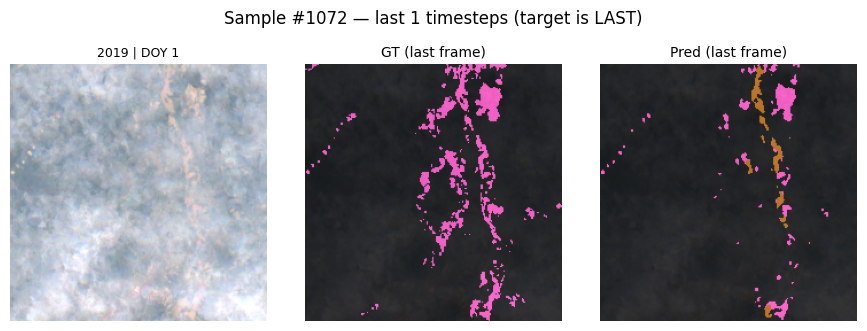

In [53]:
DEFAULT_ENCODING = {
    3: [255, 255,   0],  # yellow
    2: [180,  96,   0],  # brown-ish
    1: [251,  72, 196],  # magenta
    0: [  0,   0,   0],  # background
}

visualise_random_prediction_temporal(
    model,
    dataset=val_dataset,     # your MineFootprintTFRecordDataset with temporal stacks
    timesteps=TIMESTEPS,            # pick the last 4 frames; change as you wish
    device=device,
    colour_encoding=DEFAULT_ENCODING,
    rgb_divisor=3000.0,
    alpha=0.8,
    rgb_indices=(2,1,0),     # (R,G,B) from [BLUE,GREEN,RED,...]
)
